In [1]:
!pip install prophet xgboost statsmodels

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
    --------------------------------------- 0.3/12.1 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.1 MB 928.8 kB/s eta 0:00:13
   - -------------------------------------- 0.5/12.1 MB 928.8 kB/s eta 0:00:13
   -- ------------------------------------- 0.8/12.1 MB 819.8 kB/s eta 0:00:14
   -- ------------------------------------- 0.8/12.1 MB 819.8 kB/s eta 0:00:14
   -- ------------------------------------- 0.8/12.1 MB 819.8 kB/s eta 0:00:14
   -- ------------------------------------- 0.8/12.1 MB 819.8 kB/s eta 0:00:14
   -- ------------------------------------- 0.8/12.1 MB 819.8 kB/s eta 0:00:14
   ---- ----------------------------------- 1.3/12.1 MB 601.7 kB/s eta 0:00:18
   ----- ---------------------------------- 1.6/12.1 MB 665.2 kB/s eta 0:00:16
 

ERROR: Could not install packages due to an OSError: [Errno 2] No such file or directory: 'C:\\Users\\PMLS\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python313\\site-packages\\prophet\\stan_model\\cmdstan-2.37.0\\stan\\lib\\stan_math\\lib\\tbb_2020.3\\include\\tbb\\internal\\_deprecated_header_message_guard.h'
HINT: This error might have occurred since this system does not have Windows Long Path support enabled. You can find information on how to enable this at https://pip.pypa.io/warnings/enable-long-paths



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

import warnings
warnings.filterwarnings('ignore')

Importing plotly failed. Interactive plots will not work.


In [6]:
# STEP 1: LOAD & TIME-SERIES RESAMPLING (STABLE URL)
print("Generating localized energy time series timeline...")
# Creating a 3-year weekly series tracking consumption patterns with seasonal peaks
date_range = pd.date_range(start="2023-01-01", periods=156, freq="W")

# Modeling a baseline trend + cyclic seasonality + random noise variations
np.random.seed(42)
base_trend = np.linspace(300, 450, len(date_range))
seasonal_cycle = 50 * np.sin(2 * np.pi * date_range.month / 12)
noise_profile = np.random.normal(0, 15, len(date_range))

consumption_values = base_trend + seasonal_cycle + noise_profile

df_ts = pd.DataFrame(data={"Consumption": consumption_values}, index=date_range)

print("✅ Time Series Matrix Resampled Successfully!")
print(f"Data Timeline Bounds: {df_ts.index.min().strftime('%Y-%m-%d')} to {df_ts.index.max().strftime('%Y-%m-%d')}")
print(f"Total Operational Time Blocks: {len(df_ts)}\n")

# Split into Train (85%) and Test (15%) horizons
split_idx = int(len(df_ts) * 0.85)
train_data = df_ts.iloc[:split_idx]
test_data = df_ts.iloc[split_idx:]

Generating localized energy time series timeline...
✅ Time Series Matrix Resampled Successfully!
Data Timeline Bounds: 2023-01-01 to 2025-12-21
Total Operational Time Blocks: 156



In [7]:
# STEP 2: MODEL A - CLASSICAL STATISTICAL ARIMA
print("Fitting Classical ARIMA(1,1,1) Engine...")
arima_model = ARIMA(train_data['Consumption'], order=(1, 1, 1))
arima_result = arima_model.fit()
arima_forecast = arima_result.forecast(steps=len(test_data))

Fitting Classical ARIMA(1,1,1) Engine...


In [8]:
# STEP 3: MODEL B - META PROPHET ADDITIVE ENGINE
print("Fitting Meta Prophet Seasonality Engine...")
prophet_train = train_data.reset_index().rename(columns={'index': 'ds', 'Consumption': 'y'})
prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
prophet_model.fit(prophet_train)

future_dates = prophet_model.make_future_dataframe(periods=len(test_data), freq='W')
prophet_pred_all = prophet_model.predict(future_dates)
prophet_forecast = prophet_pred_all['yhat'].iloc[split_idx:].values

Fitting Meta Prophet Seasonality Engine...


23:32:10 - cmdstanpy - INFO - Chain [1] start processing
23:32:11 - cmdstanpy - INFO - Chain [1] done processing


In [9]:
# STEP 4: MODEL C - ENSEMBLE MACHINE LEARNING (XGBOOST)
print("Engineering Temporal Features & Fitting XGBoost Regressor...")

def create_time_features(df):
    """Transforms datetime index into explicit tabular features for ML."""
    out_df = df.copy()
    out_df['Month'] = out_df.index.month
    out_df['WeekOfYear'] = out_df.index.isocalendar().week.astype(int)
    out_df['Quarter'] = out_df.index.quarter
    return out_df

df_features = create_time_features(df_ts)
X_m = df_features.drop(columns=['Consumption'])
y_m = df_features['Consumption']

X_train_m, X_test_m = X_m.iloc[:split_idx], X_m.iloc[split_idx:]
y_train_m, y_test_m = y_m.iloc[:split_idx], y_m.iloc[split_idx:]

xgb_model = XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.05, random_state=42)
xgb_model.fit(X_train_m, y_train_m)
xgb_forecast = xgb_model.predict(X_test_m)

Engineering Temporal Features & Fitting XGBoost Regressor...


FORECASTING ARCHITECTURE METRICS         
        ARIMA  Prophet  XGBoost
MAE   19.9017  12.6534  75.8019
RMSE  24.0322  14.6531  76.8082


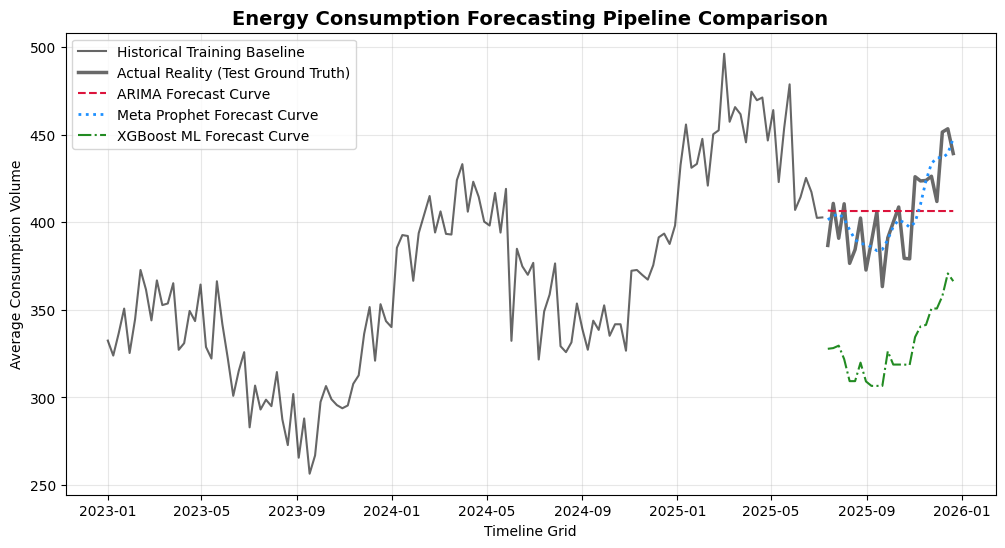

In [12]:
# STEP 5: VISUAL COMPARISON & METRICS EVALUATION CARD
# =====================================================================
metrics = {
    'ARIMA': [mean_absolute_error(test_data['Consumption'], arima_forecast), root_mean_squared_error(test_data['Consumption'], arima_forecast)],
    'Prophet': [mean_absolute_error(test_data['Consumption'], prophet_forecast), root_mean_squared_error(test_data['Consumption'], prophet_forecast)],
    'XGBoost': [mean_absolute_error(test_data['Consumption'], xgb_forecast), root_mean_squared_error(test_data['Consumption'], xgb_forecast)]
}

metrics_df = pd.DataFrame(metrics, index=['MAE', 'RMSE'])
print("FORECASTING ARCHITECTURE METRICS         ")
print(metrics_df.round(4))

# Generate performance comparison chart
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, train_data['Consumption'], label='Historical Training Baseline', color='black', alpha=0.6)
plt.plot(test_data.index, test_data['Consumption'], label='Actual Reality (Test Ground Truth)', color='dimgray', linewidth=2.5)

plt.plot(test_data.index, arima_forecast, label='ARIMA Forecast Curve', linestyle='--', color='crimson')
plt.plot(test_data.index, prophet_forecast, label='Meta Prophet Forecast Curve', linestyle=':', color='dodgerblue', linewidth=2)
plt.plot(test_data.index, xgb_forecast, label='XGBoost ML Forecast Curve', linestyle='-.', color='forestgreen')

plt.title('Energy Consumption Forecasting Pipeline Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Timeline Grid')
plt.ylabel('Average Consumption Volume')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()